# 03 - Estrategia: Momentum + RSI con Filtro de Tendencia

**Capítulo**: 03 - Momentum RSI

**Objetivo**: Implementar estrategia de RSI oversold con filtro SMA(200).

---

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import matplotlib.pyplot as plt
from curso.lib.data import download_historical
from curso.lib.indicators import sma, rsi

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

Setup completado ✓


## 1. Datos

In [5]:
TICKER = 'AAPL'
df = download_historical(TICKER)
print(f'{TICKER}: {len(df)} registros')

AAPL: 1254 registros


## 2. Indicadores

In [6]:
RSI_PERIOD = 14
SMA_TREND = 200
RSI_LOWER = 30
RSI_UPPER = 70

df['RSI'] = rsi(df, length=RSI_PERIOD)
df['SMA_200'] = sma(df, length=SMA_TREND)

# Filtro de tendencia
df['uptrend'] = df['Close'] > df['SMA_200']

# Señales
df['entry_signal'] = (df['RSI'] < RSI_LOWER) & df['uptrend']
df['exit_signal'] = df['RSI'] > RSI_UPPER

print(f'Señales de entrada: {df["entry_signal"].sum()}')
print(f'Señales de salida: {df["exit_signal"].sum()}')

Señales de entrada: 19
Señales de salida: 133


## 3. Visualización

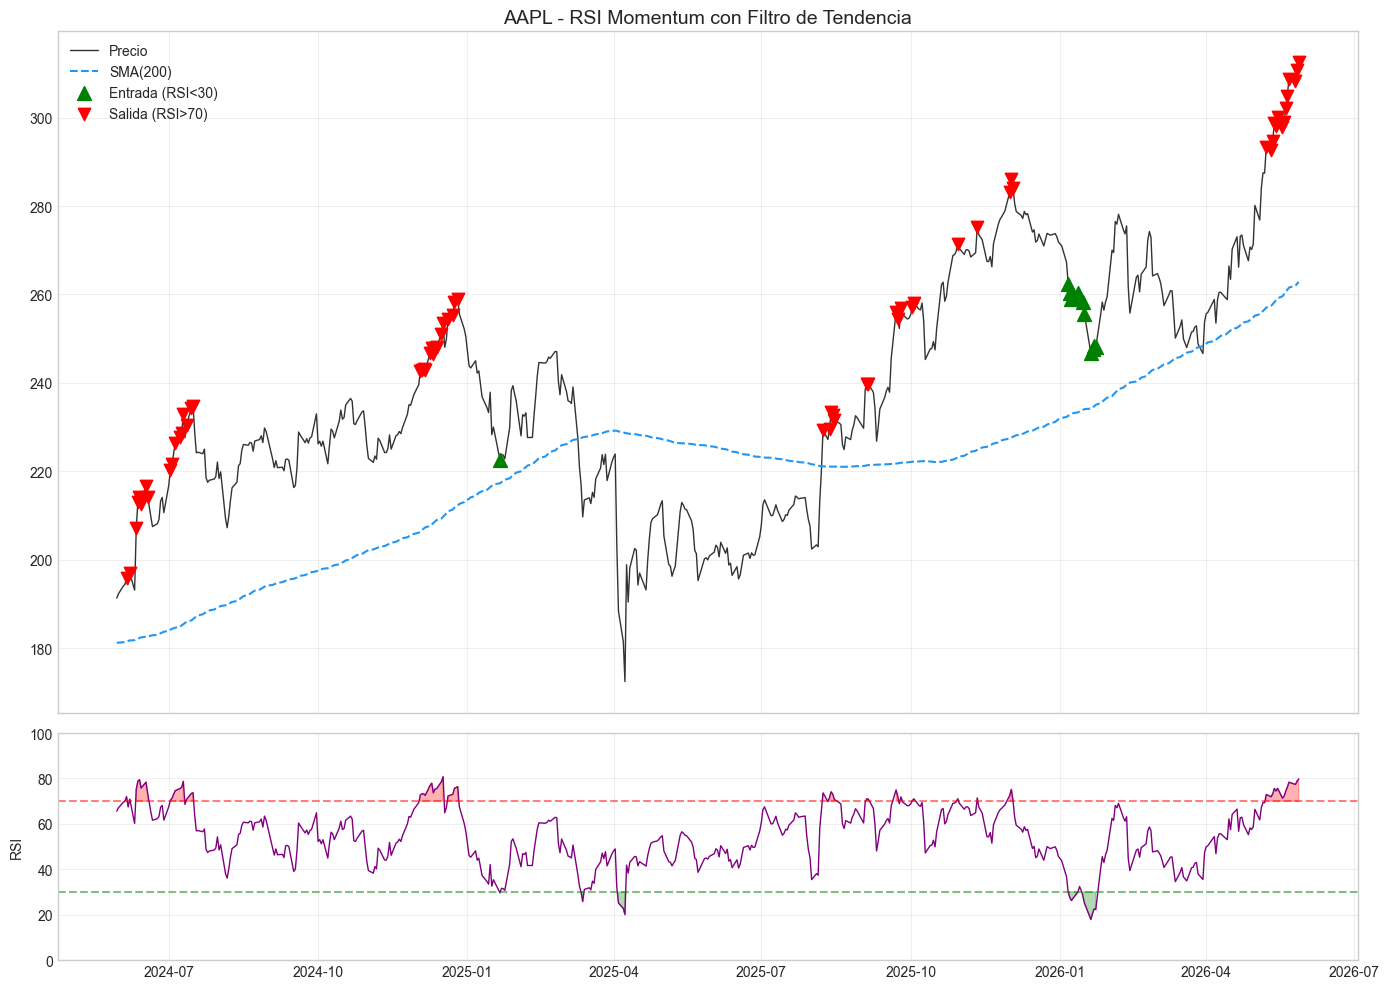

In [7]:
data = df.tail(500).copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1], sharex=True)

# Panel superior: Precio + SMA
ax1.plot(data.index, data['Close'], linewidth=1, color='#333', label='Precio')
ax1.plot(data.index, data['SMA_200'], linewidth=1.5, color='#2196F3', label='SMA(200)', linestyle='--')
entries = data[data['entry_signal']]
ax1.scatter(entries.index, entries['Close'], marker='^', color='green', s=100, zorder=5, label='Entrada (RSI<30)')
exits = data[data['exit_signal']]
ax1.scatter(exits.index, exits['Close'], marker='v', color='red', s=80, zorder=5, label='Salida (RSI>70)')
ax1.set_title(f'{TICKER} - RSI Momentum con Filtro de Tendencia', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel inferior: RSI
ax2.plot(data.index, data['RSI'], color='purple', linewidth=1)
ax2.axhline(RSI_LOWER, color='green', linestyle='--', alpha=0.5)
ax2.axhline(RSI_UPPER, color='red', linestyle='--', alpha=0.5)
ax2.fill_between(data.index, RSI_LOWER, data['RSI'], where=data['RSI'] < RSI_LOWER, alpha=0.3, color='green')
ax2.fill_between(data.index, RSI_UPPER, data['RSI'], where=data['RSI'] > RSI_UPPER, alpha=0.3, color='red')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Resumen

✅ Calculado RSI(14) y SMA(200)
✅ Aplicado filtro de tendencia
✅ Detectadas señales de entrada/salida
✅ Visualizado con panel dual (precio + RSI)

**Siguiente**: `03_backtesting.ipynb`